In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/telco_final.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (7043, 41)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_bin', 'InternetService_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin', 'num_services', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment', 'historical_CLV', 'churn_prob_proxy', 'adjusted_CLV', 'projected_CLV_12m', 'CLV_segment', 'churn_probability', 'projected_CLV_12m_updated']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,M_score,RFM_score,Segment,historical_CLV,churn_prob_proxy,adjusted_CLV,projected_CLV_12m,CLV_segment,churn_probability,projected_CLV_12m_updated
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,1,3,Lost / Inactive,29.85,1.000000,0.000000,0.000000,Low Value,0.676197,115.986195
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,2,7,At Risk,1936.30,0.555556,860.577778,303.733333,Medium Value,0.040665,655.609477
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,2,5,Lost / Inactive,107.70,0.777778,23.933333,143.600000,Low Value,0.444485,358.973749
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,...,2,7,At Risk,1903.50,0.555556,846.000000,225.600000,Medium Value,0.033314,490.689910
4,Female,0,0,0,2,1,No,Fiber optic,No,No,...,3,5,Lost / Inactive,141.40,0.777778,31.422222,188.533333,Medium Value,0.869258,110.921170


## Retention Strategy Notebook

This notebook answers the most important business question:
"Now that we know WHO will churn and WHAT they are worth, what should we actually DO about it?"

This is where data science becomes business value.
We combine three things we built:
1. RFM Segments (Notebook 2) - who are they?
2. CLV Estimates (Notebook 3) - how much are they worth?
3. Churn Probabilities (Notebook 4) - how likely are they to leave?

Output: A clear, data-driven retention playbook that a marketing or product team can act on immediately.

In [3]:
# Define high/low thresholds
clv_median = df['projected_CLV_12m_updated'].median()
churn_median = df['churn_probability'].median()

# Assign quadrant to each customer
def assign_quadrant(row):
    high_value = row['projected_CLV_12m_updated'] >= clv_median
    high_risk = row['churn_probability'] >= churn_median
    
    if high_value and high_risk:
        return 'Priority: Retain Now'
    elif high_value and not high_risk:
        return 'Protect and Reward'
    elif not high_value and high_risk:
        return 'Do Not Invest'
    else:
        return 'Low Priority'

df['strategy_quadrant'] = df.apply(assign_quadrant, axis=1)

quadrant_summary = df.groupby('strategy_quadrant').agg(
    customer_count=('churn_probability', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    avg_clv=('projected_CLV_12m_updated', 'mean'),
    total_clv=('projected_CLV_12m_updated', 'sum'),
    actual_churn_rate=('Churn', 'mean')
).reset_index()

quadrant_summary['avg_churn_prob'] = (quadrant_summary['avg_churn_prob'] * 100).round(1)
quadrant_summary['actual_churn_rate'] = (quadrant_summary['actual_churn_rate'] * 100).round(1)
quadrant_summary['avg_clv'] = quadrant_summary['avg_clv'].round(2)
quadrant_summary['total_clv'] = quadrant_summary['total_clv'].round(2)

print(quadrant_summary.to_string(index=False))

   strategy_quadrant  customer_count  avg_churn_prob  avg_clv  total_clv  actual_churn_rate
       Do Not Invest            2173            68.8   205.59  446742.08               57.0
        Low Priority            1348             4.9   249.09  335775.71                3.3
Priority: Retain Now            1349            40.9   619.74  836028.60               33.6
  Protect and Reward            2173             8.2   851.36 1850013.97                6.2


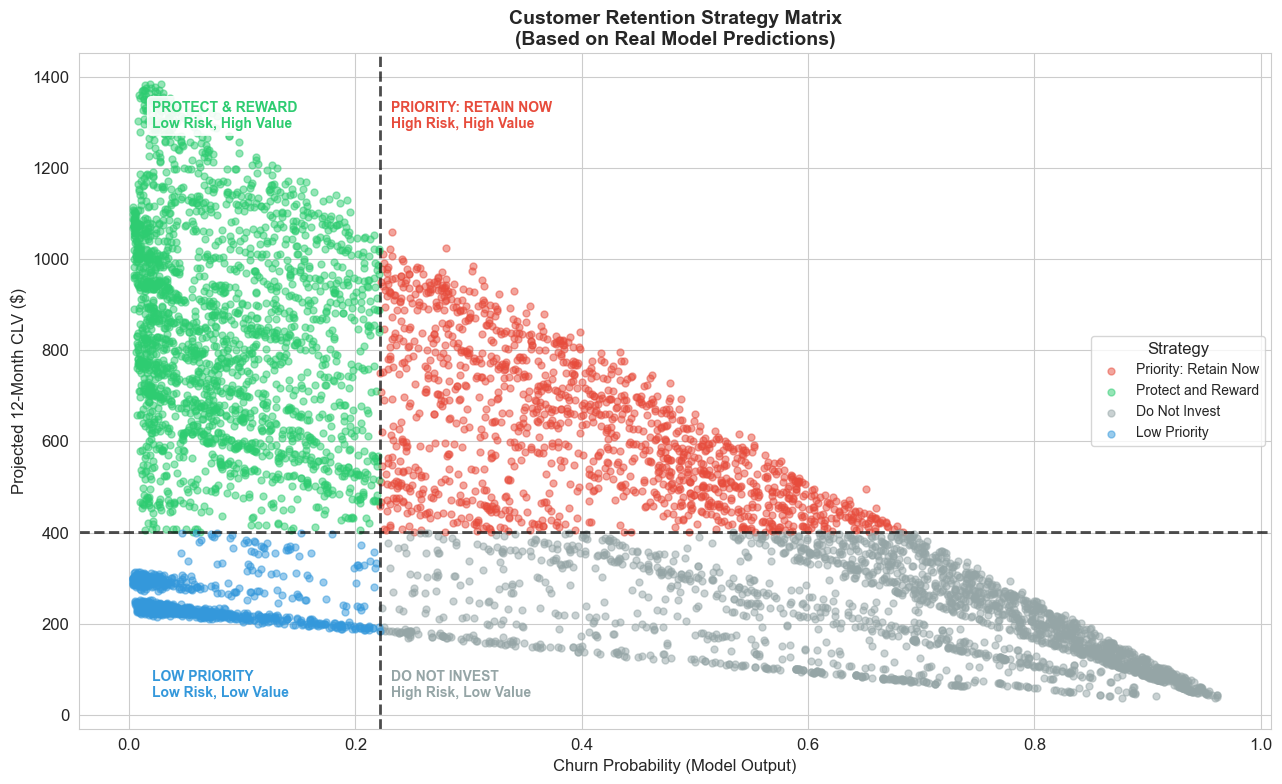

In [5]:
fig, ax = plt.subplots(figsize=(13, 8))

quadrant_colors = {
    'Priority: Retain Now': '#e74c3c',
    'Protect and Reward': '#2ecc71',
    'Do Not Invest': '#95a5a6',
    'Low Priority': '#3498db'
}

for quadrant, color in quadrant_colors.items():
    mask = df['strategy_quadrant'] == quadrant
    ax.scatter(df[mask]['churn_probability'],
               df[mask]['projected_CLV_12m_updated'],
               c=color, label=quadrant,
               alpha=0.5, s=25)

ax.axvline(x=churn_median, color='black', 
           linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(y=clv_median, color='black', 
           linestyle='--', linewidth=2, alpha=0.7)

# Quadrant labels
ax.text(0.02, df['projected_CLV_12m_updated'].max() * 0.93,
        'PROTECT & REWARD\nLow Risk, High Value',
        fontsize=10, fontweight='bold', color='#2ecc71',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.text(churn_median + 0.01, df['projected_CLV_12m_updated'].max() * 0.93,
        'PRIORITY: RETAIN NOW\nHigh Risk, High Value',
        fontsize=10, fontweight='bold', color='#e74c3c',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.text(0.02, df['projected_CLV_12m_updated'].min() + 2,
        'LOW PRIORITY\nLow Risk, Low Value',
        fontsize=10, fontweight='bold', color='#3498db',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.text(churn_median + 0.01, df['projected_CLV_12m_updated'].min() + 2,
        'DO NOT INVEST\nHigh Risk, Low Value',
        fontsize=10, fontweight='bold', color='#95a5a6',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_xlabel('Churn Probability (Model Output)', fontsize=12)
ax.set_ylabel('Projected 12-Month CLV ($)', fontsize=12)
ax.set_title('Customer Retention Strategy Matrix\n(Based on Real Model Predictions)',
             fontsize=14, fontweight='bold')
ax.legend(title='Strategy', loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/retention_strategy_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# How many customers in each quadrant and what is the revenue at stake
priority_customers = df[df['strategy_quadrant'] == 'Priority: Retain Now']
protect_customers = df[df['strategy_quadrant'] == 'Protect and Reward']
low_priority = df[df['strategy_quadrant'] == 'Low Priority']
do_not_invest = df[df['strategy_quadrant'] == 'Do Not Invest']

print("=" * 60)
print("RETENTION BUDGET ALLOCATION RECOMMENDATION")
print("=" * 60)

print(f"\n1. PRIORITY: RETAIN NOW (High Value + High Risk)")
print(f"   Customers:          {len(priority_customers):,}")
print(f"   Avg Churn Prob:     {priority_customers['churn_probability'].mean()*100:.1f}%")
print(f"   Revenue at Risk:    ${priority_customers['projected_CLV_12m_updated'].sum():,.0f}")
print(f"   Recommended Action: Immediate personal outreach, discount offers,")
print(f"                       contract upgrade incentives")

print(f"\n2. PROTECT AND REWARD (High Value + Low Risk)")
print(f"   Customers:          {len(protect_customers):,}")
print(f"   Avg Churn Prob:     {protect_customers['churn_probability'].mean()*100:.1f}%")
print(f"   Total CLV:          ${protect_customers['projected_CLV_12m_updated'].sum():,.0f}")
print(f"   Recommended Action: Loyalty rewards, early access to new features,")
print(f"                       VIP treatment to keep them happy")

print(f"\n3. LOW PRIORITY (Low Value + Low Risk)")
print(f"   Customers:          {len(low_priority):,}")
print(f"   Avg Churn Prob:     {low_priority['churn_probability'].mean()*100:.1f}%")
print(f"   Recommended Action: Standard service, low-cost engagement emails")

print(f"\n4. DO NOT INVEST (Low Value + High Risk)")
print(f"   Customers:          {len(do_not_invest):,}")
print(f"   Avg Churn Prob:     {do_not_invest['churn_probability'].mean()*100:.1f}%")
print(f"   Recommended Action: No retention spend. Let them go naturally.")
print(f"                       Focus resources elsewhere.")

total_priority_revenue = priority_customers['projected_CLV_12m_updated'].sum()
print(f"\n{'='*60}")
print(f"If we retain just 50% of Priority customers:")
print(f"Estimated revenue saved: ${total_priority_revenue * 0.5:,.0f}")
print(f"{'='*60}")

RETENTION BUDGET ALLOCATION RECOMMENDATION

1. PRIORITY: RETAIN NOW (High Value + High Risk)
   Customers:          1,349
   Avg Churn Prob:     40.9%
   Revenue at Risk:    $836,029
   Recommended Action: Immediate personal outreach, discount offers,
                       contract upgrade incentives

2. PROTECT AND REWARD (High Value + Low Risk)
   Customers:          2,173
   Avg Churn Prob:     8.2%
   Total CLV:          $1,850,014
   Recommended Action: Loyalty rewards, early access to new features,
                       VIP treatment to keep them happy

3. LOW PRIORITY (Low Value + Low Risk)
   Customers:          1,348
   Avg Churn Prob:     4.9%
   Recommended Action: Standard service, low-cost engagement emails

4. DO NOT INVEST (Low Value + High Risk)
   Customers:          2,173
   Avg Churn Prob:     68.8%
   Recommended Action: No retention spend. Let them go naturally.
                       Focus resources elsewhere.

If we retain just 50% of Priority customers:
Estima

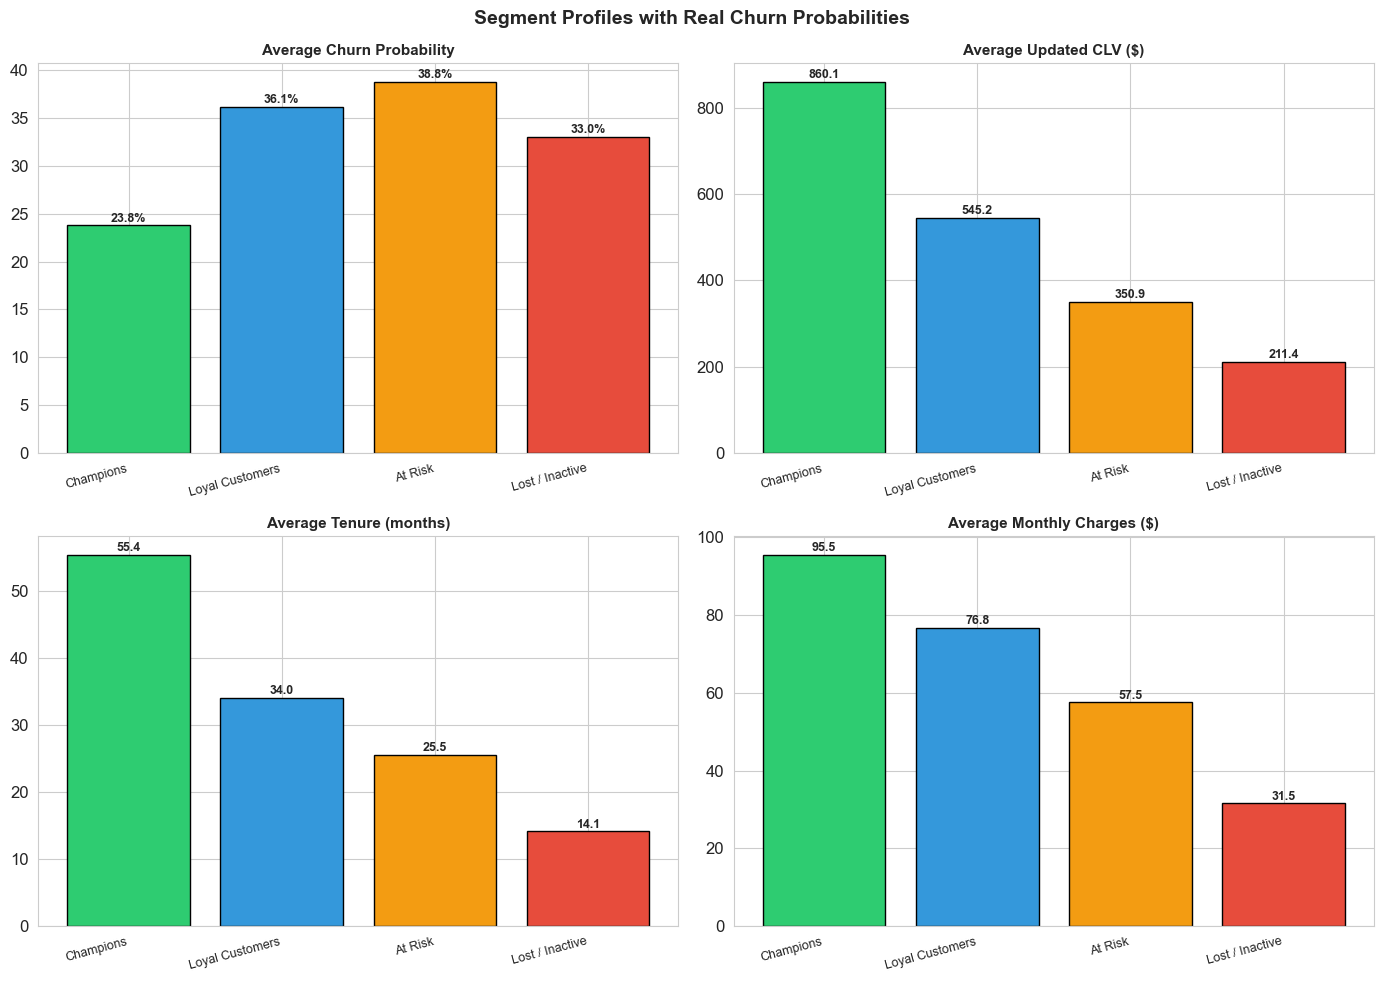

In [7]:
segment_order = ['Champions', 'Loyal Customers', 'At Risk', 'Lost / Inactive']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = [
    ('churn_probability', 'Average Churn Probability', True),
    ('projected_CLV_12m_updated', 'Average Updated CLV ($)', False),
    ('tenure', 'Average Tenure (months)', False),
    ('MonthlyCharges', 'Average Monthly Charges ($)', False)
]

for ax, (metric, title, is_pct) in zip(axes, metrics):
    values = []
    for seg in segment_order:
        val = df[df['Segment'] == seg][metric].mean()
        values.append(val * 100 if is_pct else val)
    
    bars = ax.bar(segment_order, values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(segment_order, rotation=15, ha='right', fontsize=9)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values) * 0.01,
                f'{val:.1f}{"%" if is_pct else ""}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Segment Profiles with Real Churn Probabilities',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/segment_profiles_final.png', dpi=150, bbox_inches='tight')
plt.show()

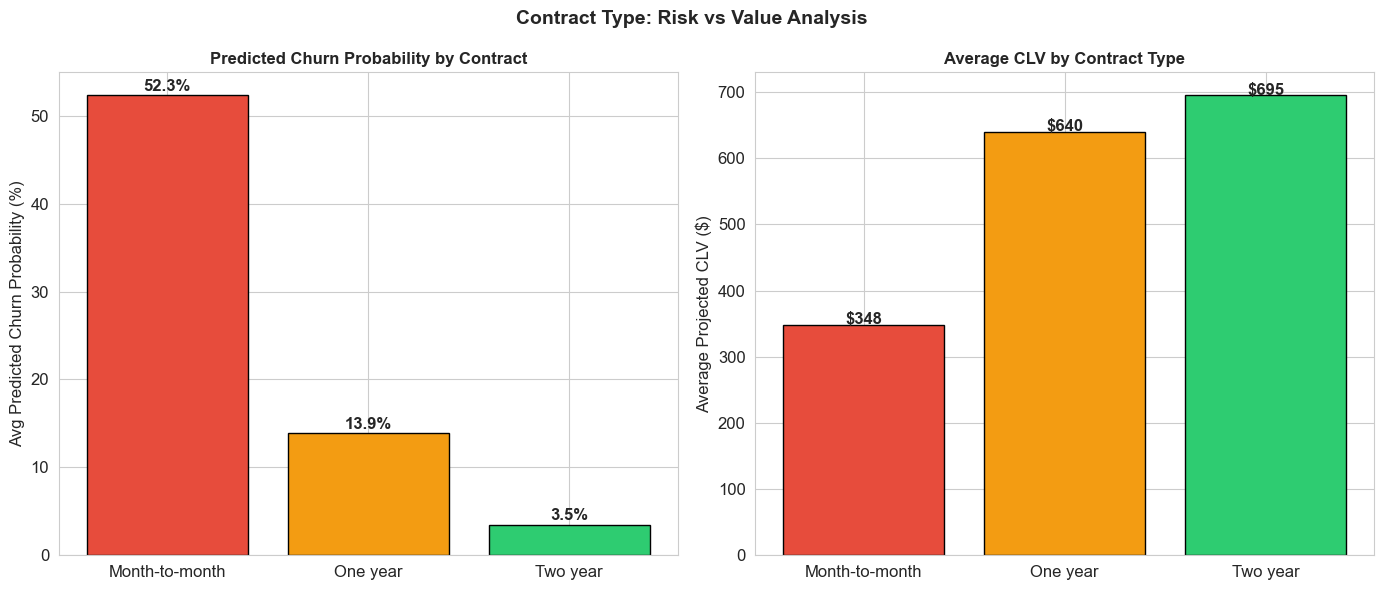


Contract Action Plan:
--------------------------------------------------

Month-to-month Contract:
  Customers:      3,875
  Churn Risk:     52.3%
  Avg CLV:        $348

One year Contract:
  Customers:      1,473
  Churn Risk:     13.9%
  Avg CLV:        $640

Two year Contract:
  Customers:      1,695
  Churn Risk:     3.5%
  Avg CLV:        $695


In [8]:
contract_analysis = df.groupby('Contract').agg(
    customer_count=('churn_probability', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    avg_clv=('projected_CLV_12m_updated', 'mean'),
    actual_churn_rate=('Churn', 'mean')
).reset_index()

contract_analysis['avg_churn_prob_pct'] = (contract_analysis['avg_churn_prob'] * 100).round(1)
contract_analysis['actual_churn_rate_pct'] = (contract_analysis['actual_churn_rate'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
contract_colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars1 = axes[0].bar(contract_analysis['Contract'],
                     contract_analysis['avg_churn_prob_pct'],
                     color=contract_colors, edgecolor='black')
axes[0].set_title('Predicted Churn Probability by Contract', 
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Predicted Churn Probability (%)')

for bar, val in zip(bars1, contract_analysis['avg_churn_prob_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontweight='bold')

bars2 = axes[1].bar(contract_analysis['Contract'],
                     contract_analysis['avg_clv'],
                     color=contract_colors, edgecolor='black')
axes[1].set_title('Average CLV by Contract Type',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Projected CLV ($)')

for bar, val in zip(bars2, contract_analysis['avg_clv']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'${val:.0f}', ha='center', fontweight='bold')

plt.suptitle('Contract Type: Risk vs Value Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/contract_action_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nContract Action Plan:")
print("-" * 50)
for _, row in contract_analysis.iterrows():
    print(f"\n{row['Contract']} Contract:")
    print(f"  Customers:      {row['customer_count']:,}")
    print(f"  Churn Risk:     {row['avg_churn_prob_pct']}%")
    print(f"  Avg CLV:        ${row['avg_clv']:.0f}")

In [10]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           FINAL RETENTION STRATEGY RECOMMENDATIONS           ║
╚══════════════════════════════════════════════════════════════╝

IMMEDIATE ACTIONS (Next 30 Days):
─────────────────────────────────
1. Target "Priority: Retain Now" customers with personal outreach
   - Offer contract upgrade from month-to-month to annual
   - Provide 10-15% discount on monthly charges
   - Assign dedicated customer success representative

2. Protect "Champions" and "Loyal Customers"
   - Early access to new features or service upgrades
   - Loyalty reward program enrollment
   - Proactive satisfaction check-ins

MEDIUM TERM ACTIONS (Next 90 Days):
────────────────────────────────────
3. New customer onboarding improvement
   - Most churn happens in first 12 months
   - Implement 30/60/90 day check-in program
   - Offer first-year incentives to encourage contract commitment

4. Fiber optic customer satisfaction review
   - Fiber customers churn at highest rate despite premium pricing
   - Conduct satisfaction surveys to identify pain points
   - Consider service quality improvements or pricing review

DO NOT DO:
──────────
5. Do not spend retention budget on "Do Not Invest" quadrant
   - These customers are low value AND high risk
   - Retention cost will exceed recovered revenue
   - Reallocate that budget to Priority customers instead

EXPECTED IMPACT:
────────────────
- Retaining 50% of Priority customers saves significant revenue
- Reducing new customer churn by 20% through better onboarding increases average tenure and lifetime value across all segments
- Shifting 10% of month-to-month customers to annual contracts reduces overall churn rate by approximately 3-4 percentage points
""")


╔══════════════════════════════════════════════════════════════╗
║           FINAL RETENTION STRATEGY RECOMMENDATIONS           ║
╚══════════════════════════════════════════════════════════════╝

IMMEDIATE ACTIONS (Next 30 Days):
─────────────────────────────────
1. Target "Priority: Retain Now" customers with personal outreach
   - Offer contract upgrade from month-to-month to annual
   - Provide 10-15% discount on monthly charges
   - Assign dedicated customer success representative

2. Protect "Champions" and "Loyal Customers"
   - Early access to new features or service upgrades
   - Loyalty reward program enrollment
   - Proactive satisfaction check-ins

MEDIUM TERM ACTIONS (Next 90 Days):
────────────────────────────────────
3. New customer onboarding improvement
   - Most churn happens in first 12 months
   - Implement 30/60/90 day check-in program
   - Offer first-year incentives to encourage contract commitment

4. Fiber optic customer satisfaction review
   - Fiber customers

In [11]:
# Add strategy quadrant to final dataset
output_cols = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService',
               'Segment', 'CLV_segment', 'churn_probability',
               'projected_CLV_12m_updated', 'strategy_quadrant', 'Churn']

final_output = df[output_cols].copy()
final_output.to_csv('../data/processed/telco_strategy.csv', index=False)

print("Saved: data/processed/telco_strategy.csv")
print(f"\nStrategy Quadrant Distribution:")
print(final_output['strategy_quadrant'].value_counts())
print(f"\nThis file is ready for Power BI dashboard import.")

Saved: data/processed/telco_strategy.csv

Strategy Quadrant Distribution:
strategy_quadrant
Do Not Invest           2173
Protect and Reward      2173
Priority: Retain Now    1349
Low Priority            1348
Name: count, dtype: int64

This file is ready for Power BI dashboard import.



### Project Pipeline:
| Notebook | What It Does |
|----------|-------------|
| 01 EDA | Discovered contract type and tenure as top churn drivers |
| 02 RFM | Segmented 7,043 customers into 4 behavioral groups |
| 03 CLV | Estimated 12-month revenue value for every customer |
| 04 Model | XGBoost with 89% AUC, SMOTE, SHAP explainability |
| 05 Strategy | Translated model output into actionable business plan |

### Key Business Insights:
- Month-to-month customers churn at 14x the rate of two-year customers
- Most churn happens in the first 12 months of tenure
- Priority retention targets identified with revenue at risk quantified
- Clear budget allocation: focus spend on high value, high risk customers

### Tech Stack:
Python, Pandas, Scikit-learn, XGBoost, SHAP, Matplotlib, Seaborn
